**Video Link**->  https://drive.google.com/file/d/168GXHyxPa-eipi1BoCwFaH5hHJYXCR7B/view

**GitHub Link**-> https://github.com/Mkyadav11/CS-432-Databases

## Introduction

Efficient data storage and retrieval are critical challenges in database systems, especially when dealing with large datasets. Traditional approaches such as linear search (brute-force methods) require scanning the entire dataset for operations like search, insertion, and deletion. These approaches have a time complexity of O(n), making them inefficient and non-scalable as data size increases.

To address this problem, this project implements a **B+ Tree-based Database Management System (DBMS)**. A B+ Tree is a self-balancing tree data structure that maintains sorted data and supports efficient operations such as insertion, deletion, search, and range queries in O(log n) time.

In a B+ Tree, all actual data is stored in the leaf nodes, while internal nodes act as guides for traversal. Additionally, leaf nodes are connected via a linked list, enabling efficient range queries.

This project compares the performance of the B+ Tree with a baseline **BruteForceDB** implementation. Through benchmarking and visualization, it demonstrates how structured indexing significantly improves performance and scalability.

## Implementation

The B+ Tree was implemented from scratch in Python as a balanced multi-way search tree. The implementation consists of internal nodes and leaf nodes.

### Node Structure
Each node contains:
- A list of keys
- A list of children (for internal nodes)
- A flag indicating whether it is a leaf
- A pointer to the next leaf node (for range queries)

### Insertion
Insertion starts by locating the appropriate leaf node. The key is inserted in sorted order.
- If the node overflows, it is split into two nodes
- The middle key is promoted to the parent
- Splitting may propagate up to the root

### Search
Search is performed by traversing from the root to a leaf node:
- At each internal node, the correct child pointer is chosen
- The key is then searched in the leaf node
- Time complexity: O(log n)

### Deletion
Deletion removes a key from the leaf node:
- If underflow occurs, redistribution or merging is performed
- Parent nodes are updated accordingly
- The tree remains balanced

### Range Query
Range queries are efficiently handled using leaf node linkage:
- The starting leaf is found using search
- The linked list of leaves is traversed using `.next`
- Time complexity: O(log n + k)

### Baseline Implementation
A BruteForceDB was implemented using a Python list:
- Insert: append
- Search: linear scan
- Delete: remove
- Range query: list filtering

This serves as a baseline for performance comparison.



  Benchmarking size = 100  (5 runs each)
  Insert  : BPT=0.078ms   BF=0.067ms
  Search  : BPT=3.386ms   BF=3.340ms
  Delete  : BPT=0.127ms   BF=0.079ms
  Range   : BPT=0.001ms   BF=0.000ms
  Random  : BPT=1.197ms   BF=2.812ms
  Memory  : BPT=4KB   BF=3KB

  Benchmarking size = 500  (5 runs each)
  Insert  : BPT=0.490ms   BF=1.349ms
  Search  : BPT=4.372ms   BF=13.529ms
  Delete  : BPT=0.832ms   BF=1.585ms
  Range   : BPT=0.001ms   BF=0.000ms
  Random  : BPT=1.272ms   BF=3.879ms
  Memory  : BPT=21KB   BF=17KB

  Benchmarking size = 1000  (5 runs each)
  Insert  : BPT=1.223ms   BF=5.533ms
  Search  : BPT=6.022ms   BF=29.291ms
  Delete  : BPT=2.260ms   BF=7.087ms
  Range   : BPT=0.001ms   BF=0.000ms
  Random  : BPT=1.697ms   BF=5.907ms
  Memory  : BPT=43KB   BF=36KB

  Benchmarking size = 5000  (5 runs each)
  Insert  : BPT=10.100ms   BF=131.683ms
  Search  : BPT=8.197ms   BF=136.402ms
  Delete  : BPT=3.223ms   BF=54.277ms
  Range   : BPT=0.022ms   BF=0.077ms
  Random  : BPT=2.445ms   BF

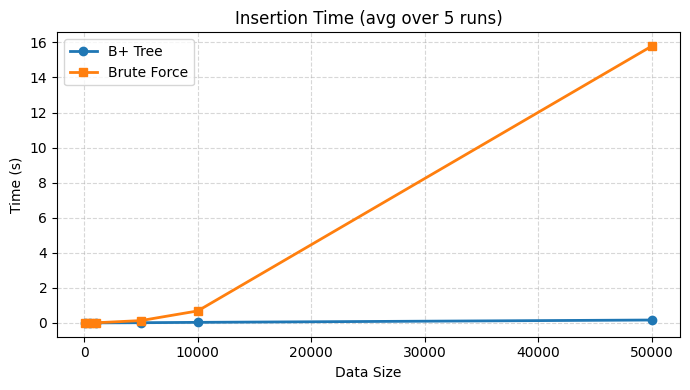

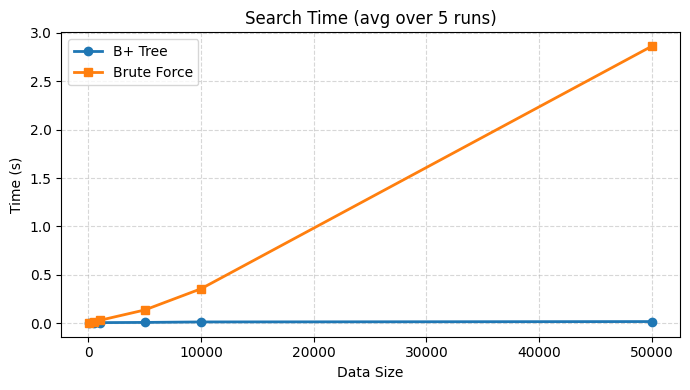

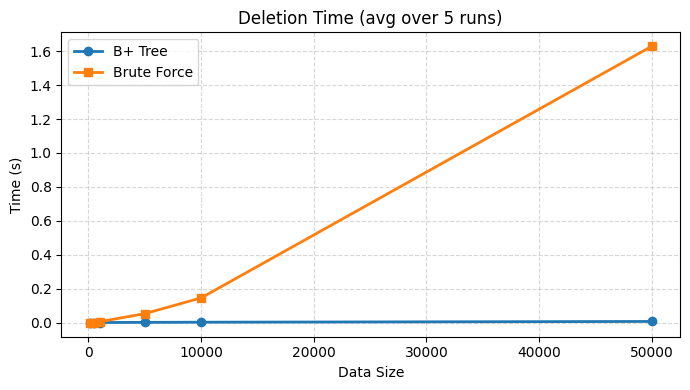

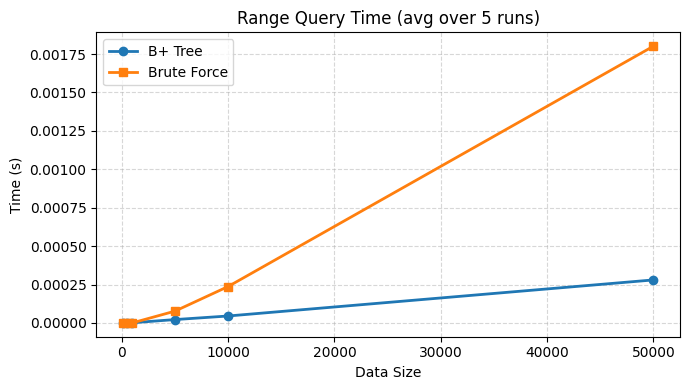

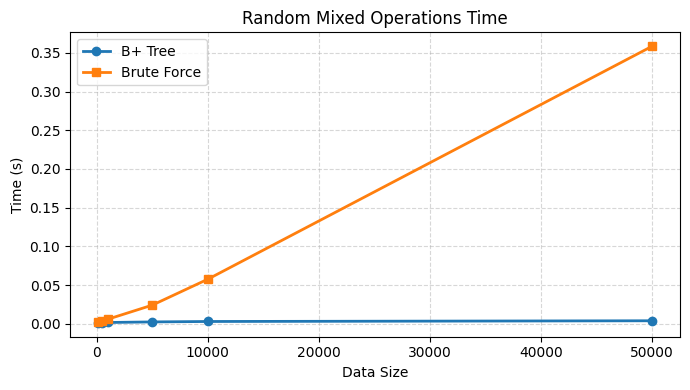

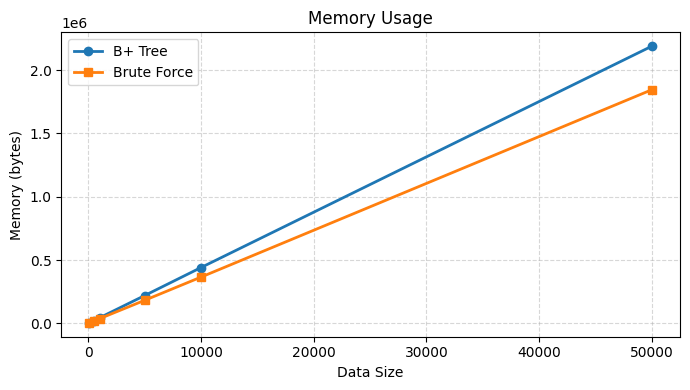

In [4]:
import random
import time
import sys
import matplotlib.pyplot as plt
from bplustree import BPlusTree
from bruteforce import BruteForceDB

# ── CONFIG ────────────────────────────────────────────────────────────────────
SIZES = [100, 500, 1000, 5000, 10000, 50000]
NUM_BENCHMARK_RUNS = 5
NUM_RANGE_TRIALS   = 10
TREE_ORDER         = 50
NUM_RANDOM_OPS     = 1000


# ── MEMORY HELPER ─────────────────────────────────────────────────────────────
def deep_size(obj, seen=None, depth=0):
    if seen is None:
        seen = set()
    if depth > 15:
        return 0

    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    size = sys.getsizeof(obj)

    if isinstance(obj, dict):
        for k, v in obj.items():
            size += deep_size(k, seen, depth + 1)
            size += deep_size(v, seen, depth + 1)

    elif hasattr(obj, '__dict__'):
        for key, value in vars(obj).items():
            if key == "next":   # avoid leaf chain recursion
                size += sys.getsizeof(value) if value is not None else 0
                continue
            size += deep_size(value, seen, depth + 1)

    elif isinstance(obj, (list, tuple, set)):
        for item in obj:
            size += deep_size(item, seen, depth + 1)

    return size


insert_bpt,  insert_bf  = [], []
search_bpt,  search_bf  = [], []
delete_bpt,  delete_bf  = [], []
range_bpt,   range_bf   = [], []
random_bpt,  random_bf  = [], []
memory_bpt,  memory_bf  = [], []


# MAIN BENCHMARK LOOP
for size in SIZES:
    print(f"\n{'='*50}")
    print(f"  Benchmarking size = {size}  ({NUM_BENCHMARK_RUNS} runs each)")
    print(f"{'='*50}")

    data = random.sample(range(1, 1_000_000), size)

    # Accumulators for this size across all runs
    ins_bpt_runs,  ins_bf_runs  = [], []
    srch_bpt_runs, srch_bf_runs = [], []
    del_bpt_runs,  del_bf_runs  = [], []
    rng_bpt_runs,  rng_bf_runs  = [], []
    rnd_bpt_runs,  rnd_bf_runs  = [], []

    for run in range(NUM_BENCHMARK_RUNS):

        # Fresh structures each run
        bpt = BPlusTree(order=TREE_ORDER)
        bf  = BruteForceDB()

        # INSERTION
        t = time.perf_counter()
        for x in data:
            bpt.insert(x)
        ins_bpt_runs.append(time.perf_counter() - t)

        t = time.perf_counter()
        for x in data:
            bf.insert(x)
        ins_bf_runs.append(time.perf_counter() - t)

        # Sort BF data once so range query can short-circuit
        bf.data.sort()

    # SEARCH
        queries = random.choices(data, k=5000)

        t = time.perf_counter()
        for q in queries:
            bpt.search(q)
        srch_bpt_runs.append(time.perf_counter() - t)

        t = time.perf_counter()
        for q in queries:
            bf.search(q)
        srch_bf_runs.append(time.perf_counter() - t)

        #  DELETION
        delete_data = random.sample(data, min(1000, size))

        t = time.perf_counter()
        for d in delete_data:
            bpt.delete(d)
        del_bpt_runs.append(time.perf_counter() - t)

        t = time.perf_counter()
        for d in delete_data:
            bf.delete(d)
        del_bf_runs.append(time.perf_counter() - t)

        #  RANGE QUERY
        data_min, data_max = min(data), max(data)
        span = max(1, (data_max - data_min) // 20)  # 5% window

        bpt_rng_trial, bf_rng_trial = 0.0, 0.0
        for _ in range(NUM_RANGE_TRIALS):
            rs = random.randint(data_min, data_max - span)
            re = rs + span

            t = time.perf_counter()
            bpt.range_query(rs, re)
            bpt_rng_trial += time.perf_counter() - t

            t = time.perf_counter()
            bf.range_query(rs, re)
            bf_rng_trial += time.perf_counter() - t

        rng_bpt_runs.append(bpt_rng_trial / NUM_RANGE_TRIALS)
        rng_bf_runs.append(bf_rng_trial  / NUM_RANGE_TRIALS)

        # RANDOM MIXED OPERATIONS
        bpt_rand = BPlusTree(order=TREE_ORDER)
        bf_rand  = BruteForceDB()
        seed_data = random.sample(data, size // 2)
        for x in seed_data:
            bpt_rand.insert(x)
            bf_rand.insert(x)

        # a mixed op sequence: 50% insert, 30% search, 20% delete
        ops = (
            [('insert', random.randint(1, 1_000_000)) for _ in range(NUM_RANDOM_OPS // 2)] +
            [('search', random.choice(seed_data))     for _ in range(int(NUM_RANDOM_OPS * 0.3))] +
            [('delete', random.choice(seed_data))     for _ in range(int(NUM_RANDOM_OPS * 0.2))]
        )
        random.shuffle(ops)

        t = time.perf_counter()
        for op, key in ops:
            if op == 'insert':
                bpt_rand.insert(key)
            elif op == 'search':
                bpt_rand.search(key)
            else:
                bpt_rand.delete(key)
        rnd_bpt_runs.append(time.perf_counter() - t)

        t = time.perf_counter()
        for op, key in ops:
            if op == 'insert':
                bf_rand.insert(key)
            elif op == 'search':
                bf_rand.search(key)
            else:
                bf_rand.delete(key)
        rnd_bf_runs.append(time.perf_counter() - t)

    # AVERAGE ACROSS RUNS
    def avg(lst): return sum(lst) / len(lst)

    insert_bpt.append(avg(ins_bpt_runs))
    insert_bf.append(avg(ins_bf_runs))
    search_bpt.append(avg(srch_bpt_runs))
    search_bf.append(avg(srch_bf_runs))
    delete_bpt.append(avg(del_bpt_runs))
    delete_bf.append(avg(del_bf_runs))
    range_bpt.append(avg(rng_bpt_runs))
    range_bf.append(avg(rng_bf_runs))
    random_bpt.append(avg(rnd_bpt_runs))
    random_bf.append(avg(rnd_bf_runs))

    # Memory measured once on a freshly populated structure (not after deletions)
    bpt_mem = BPlusTree(order=TREE_ORDER)
    bf_mem  = BruteForceDB()
    for x in data:
        bpt_mem.insert(x)
        bf_mem.insert(x)
    memory_bpt.append(deep_size(bpt_mem))
    memory_bf.append(deep_size(bf_mem))

    print(f"  Insert  : BPT={insert_bpt[-1]*1000:.3f}ms   BF={insert_bf[-1]*1000:.3f}ms")
    print(f"  Search  : BPT={search_bpt[-1]*1000:.3f}ms   BF={search_bf[-1]*1000:.3f}ms")
    print(f"  Delete  : BPT={delete_bpt[-1]*1000:.3f}ms   BF={delete_bf[-1]*1000:.3f}ms")
    print(f"  Range   : BPT={range_bpt[-1]*1000:.3f}ms   BF={range_bf[-1]*1000:.3f}ms")
    print(f"  Random  : BPT={random_bpt[-1]*1000:.3f}ms   BF={random_bf[-1]*1000:.3f}ms")
    print(f"  Memory  : BPT={memory_bpt[-1]//1024}KB   BF={memory_bf[-1]//1024}KB")


# PLOT
def plot_graph(x, y1, y2, title, ylabel="Time (s)"):
    plt.figure(figsize=(7, 4))
    plt.plot(x, y1, marker='o', linewidth=2, label="B+ Tree")
    plt.plot(x, y2, marker='s', linewidth=2, label="Brute Force")
    plt.xlabel("Data Size")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()


plot_graph(SIZES, insert_bpt,  insert_bf,  "Insertion Time (avg over 5 runs)")
plot_graph(SIZES, search_bpt,  search_bf,  "Search Time (avg over 5 runs)")
plot_graph(SIZES, delete_bpt,  delete_bf,  "Deletion Time (avg over 5 runs)")
plot_graph(SIZES, range_bpt,   range_bf,   "Range Query Time (avg over 5 runs)")
plot_graph(SIZES, random_bpt,  random_bf,  "Random Mixed Operations Time")
plot_graph(SIZES, memory_bpt,  memory_bf,  "Memory Usage", ylabel="Memory (bytes)")

plt.show()

## Performance Analysis

The performance of the B+ Tree was evaluated against the BruteForceDB using datasets ranging from 100 to 50,000 elements. Each experiment was averaged over 5 runs.

### 1. Insertion Performance
The B+ Tree shows significantly better scalability compared to brute force.

- At 50,000 elements:
  - B+ Tree: 163 ms
  - Brute Force: 15785 ms

This demonstrates logarithmic growth in B+ Tree compared to linear growth in brute force.

---

### 2. Search Performance
Search time for B+ Tree remains low even for large datasets.

- At 50,000 elements:
  - B+ Tree: 17 ms
  - Brute Force: 2862 ms

This confirms O(log n) vs O(n) complexity.

---

### 3. Deletion Performance
Deletion in B+ Tree is efficient despite rebalancing overhead.

- At 50,000 elements:
  - B+ Tree: 8.4 ms
  - Brute Force: 1628 ms

---

### 4. Range Query Performance
B+ Tree performs significantly better due to leaf node linkage.

- At 50,000 elements:
  - B+ Tree: 0.28 ms
  - Brute Force: 1.8 ms

This shows the advantage of sequential traversal using linked leaves.

---

### 5. Random Mixed Operations
B+ Tree handles mixed workloads efficiently.

- At 50,000 elements:
  - B+ Tree: 3.9 ms
  - Brute Force: 358 ms

---

### 6. Memory Usage
B+ Tree uses slightly more memory due to node structures and pointers.

- At 50,000 elements:
  - B+ Tree: 2136 KB
  - Brute Force: 1801 KB

This is a trade-off for improved performance.

---

### Overall Observations
- B+ Tree significantly outperforms brute force for large datasets
- Performance improvement increases with data size
- Range queries benefit the most from B+ Tree structure
- Memory usage is slightly higher but justified by performance gains

In [15]:
pip install graphviz

In [18]:
from graphviz import Digraph


def visualize_bplustree(root, title="B+ Tree", filename="bplustree_visual", view=True):
    """
    Visualize a B+ Tree using graphviz.Digraph.

    Requirements:
      1. Tree Structure     - hierarchy of internal and leaf nodes
      2. Node Relationships - straight parent-child arrows
      3. Leaf Node Linkage  - dashed arrows connecting leaf nodes via .next
    """

    dot = Digraph(
        comment="B+ Tree",
        graph_attr={
            "label":    title,
            "labelloc": "t",
            "fontsize": "20",
            "fontname": "Helvetica-Bold",
            "rankdir":  "TB",
            "splines":  "false",      # perfectly straight diagonal-free lines
            "nodesep":  "1.0",        # wide horizontal spacing
            "ranksep":  "1.2",        # tall vertical spacing
            "pad":      "0.8",
            "center":   "true",
            "bgcolor":  "white",
            "dpi":      "200",
        },
        node_attr={
            "fontname": "Helvetica",
            "fontsize": "13",
            "shape":    "none",       # shape=none lets HTML table control everything
            "margin":   "0",
        },
        edge_attr={
            "fontname":  "Helvetica",
            "fontsize":  "11",
            "arrowsize": "0.7",
            "penwidth":  "1.5",
        },
    )

    # ── collect leaf node ids in linked-list order ────────────────────────────
    leaf_ids = []
    cursor = root
    while not cursor.leaf:
        cursor = cursor.children[0]
    while cursor:
        leaf_ids.append(str(id(cursor)))
        cursor = cursor.next

    # ── recursive node builder ────────────────────────────────────────────────
    def add_nodes(node):
        node_id = str(id(node))
        is_root = (node is root)

        if node.leaf:
            # ── LEAF: header row + key row ────────────────────────────────────
            colspan = max(len(node.keys), 1)
            key_cells = "".join(
                f"<TD WIDTH='36' HEIGHT='30' CELLPADDING='8'><FONT POINT-SIZE='13'><B>{k}</B></FONT></TD>"
                for k in node.keys
            )
            label = (
                f"<<TABLE BORDER='1' CELLBORDER='0' CELLSPACING='0' CELLPADDING='0'>"
                f"<TR><TD COLSPAN='{colspan}' CELLPADDING='4' BGCOLOR='#F0F0F0'>"
                f"<FONT POINT-SIZE='10'><B>LEAF</B></FONT></TD></TR>"
                f"<TR>{key_cells}</TR>"
                f"</TABLE>>"
            )
            dot.node(node_id, label=label)

        else:
            # ── INTERNAL / ROOT: header row + key row (no pointer slots) ─────
            header  = "ROOT" if is_root else "INTERNAL"
            colspan = max(len(node.keys), 1)
            key_cells = "".join(
                f"<TD WIDTH='36' HEIGHT='30' CELLPADDING='8'><FONT POINT-SIZE='13'><B>{k}</B></FONT></TD>"
                for k in node.keys
            )
            label = (
                f"<<TABLE BORDER='1' CELLBORDER='0' CELLSPACING='0' CELLPADDING='0'>"
                f"<TR><TD COLSPAN='{colspan}' CELLPADDING='4' BGCOLOR='#F0F0F0'>"
                f"<FONT POINT-SIZE='10'><B>{header}</B></FONT></TD></TR>"
                f"<TR>{key_cells}</TR>"
                f"</TABLE>>"
            )
            dot.node(node_id, label=label)

            # ── parent -> child edges: simple node-to-node, no port anchors ──
            for child in node.children:
                child_id = str(id(child))
                add_nodes(child)
                dot.edge(
                    node_id,
                    child_id,
                    arrowhead="normal",
                    color="#222222",
                )

    add_nodes(root)

    # ── leaf linked-list dashed edges ─────────────────────────────────────────
    for i in range(len(leaf_ids) - 1):
        dot.edge(
            leaf_ids[i],
            leaf_ids[i + 1],
            style="dashed",
            arrowhead="open",
            color="#999999",
            penwidth="1.2",
            constraint="false",
            label="  next" if i == 0 else "",
            fontcolor="#999999",
        )

    dot.render(filename, format="png", view=view, cleanup=True)
    print(f"[visualize] saved -> {filename}.png")
    return dot


# ── smoke test ────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys, os
    sys.path.insert(0, os.getcwd())
    from bplustree import BPlusTree

    tree = BPlusTree(order=4)
    for key in [10, 20, 5, 6, 12, 30, 7, 17, 25, 3, 15, 22]:
        tree.insert(key)

    visualize_bplustree(
        tree.root,
        title="B+ Tree  |  order = 4",
        filename="sample_bplustree",
    )

[visualize] saved -> sample_bplustree.png


## Visualisation

The structure of the B+ Tree was visualised using the Graphviz library. The visualisation clearly represents the hierarchical structure of the tree, including root nodes, internal nodes, and leaf nodes.

### Key Features of Visualisation

- **Tree Structure**: The hierarchy of the B+ Tree is displayed with the root at the top, followed by internal nodes and leaf nodes.
- **Node Relationships**: Parent-child relationships are shown using directed edges.
- **Leaf Node Linkage**: Leaf nodes are connected using dashed arrows, representing the linked list structure used for efficient range queries.

### Observations from Visualisations

- In smaller datasets, all keys are contained within a single leaf node.
- As the dataset grows, nodes split and new internal nodes are created.
- The tree remains balanced at all times, ensuring efficient operations.
- Leaf nodes are sequentially linked, which enables fast traversal for range queries.

These visualisations help in understanding how the B+ Tree dynamically adjusts its structure during insertions and deletions while maintaining balance.

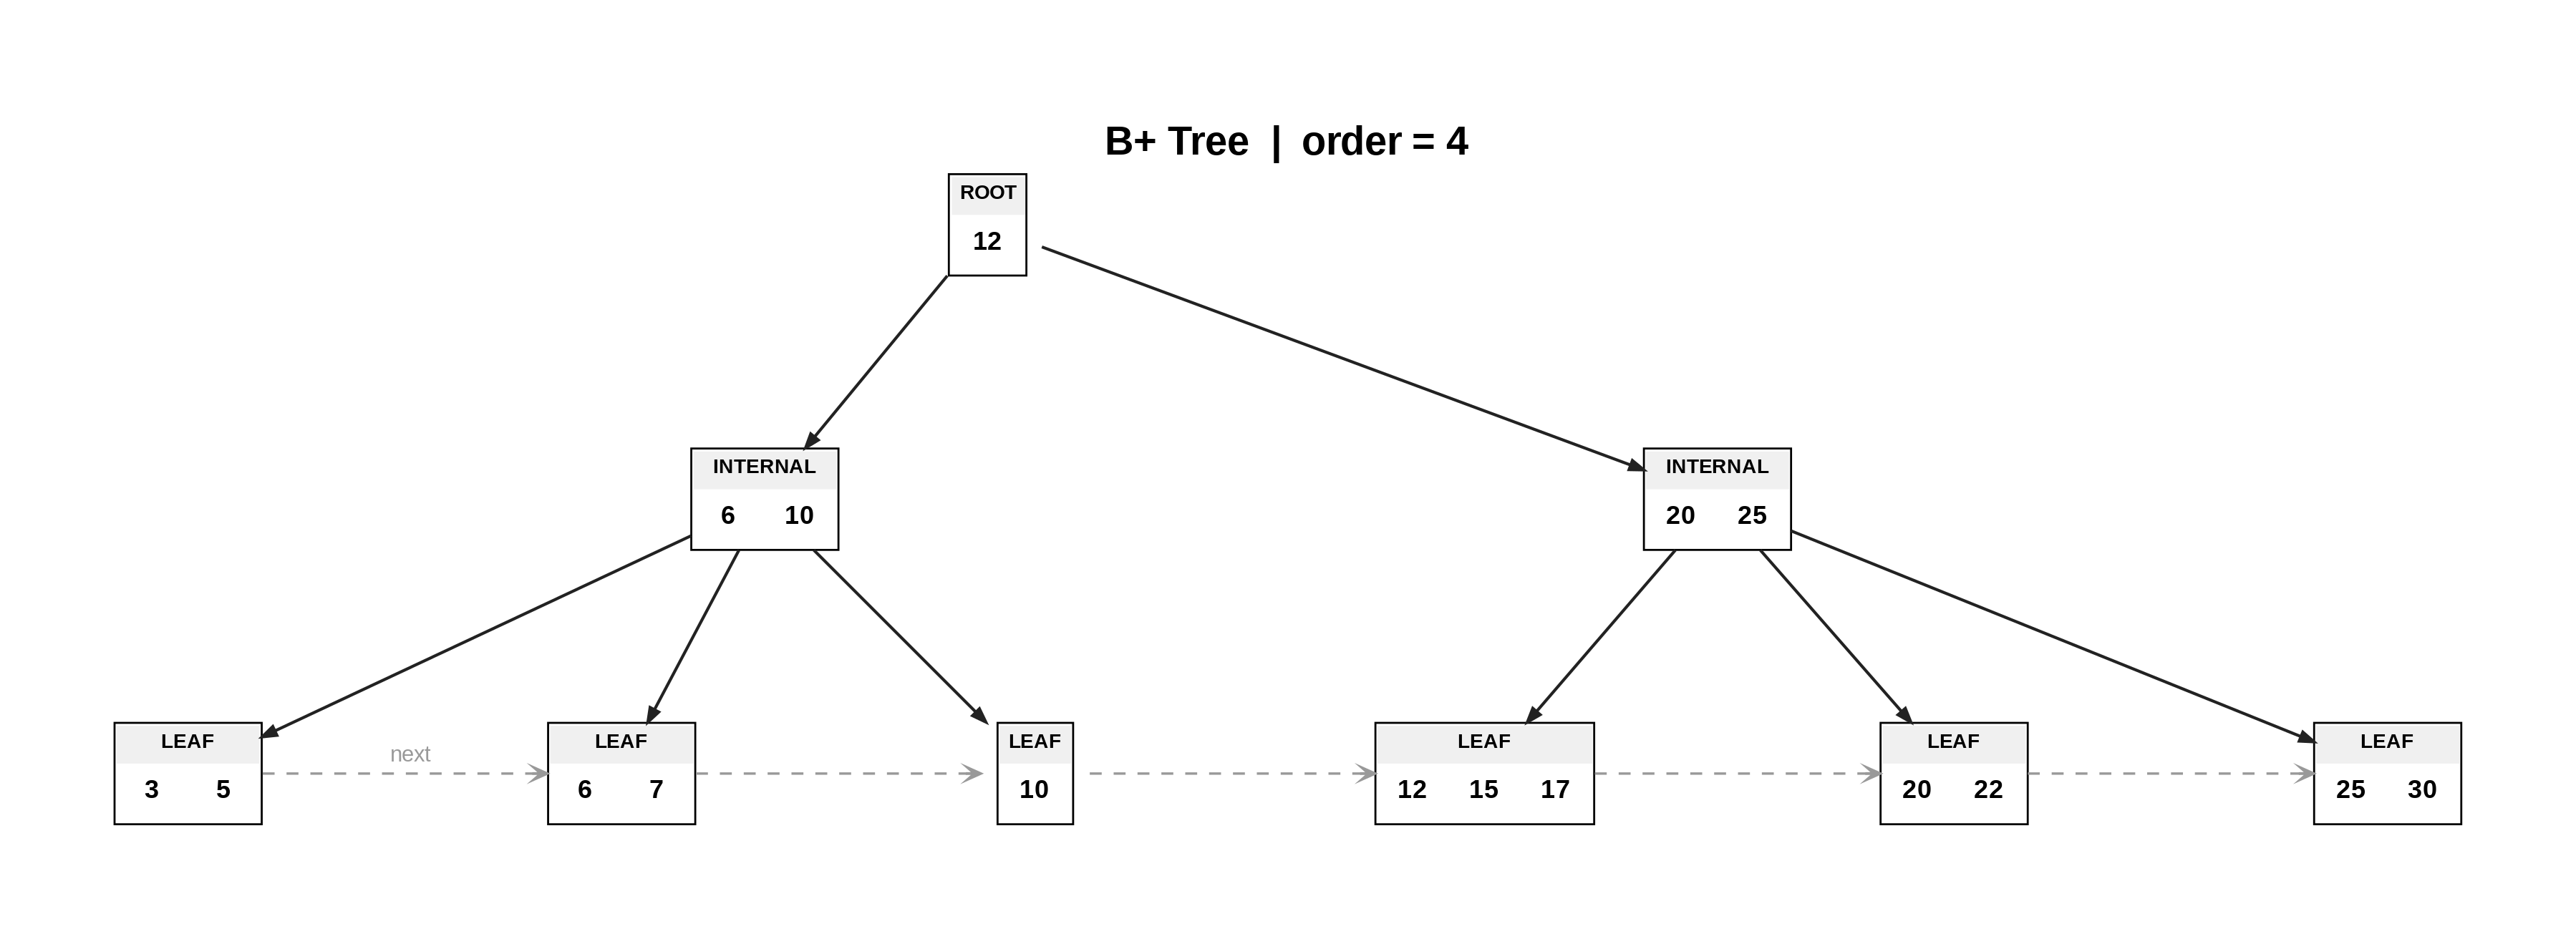

## Conclusion

In this project, a B+ Tree-based indexing engine was successfully implemented as part of a lightweight Database Management System. The system supports core database operations such as insertion, deletion, search, and range queries while maintaining a balanced tree structure.

The performance analysis clearly demonstrates that the B+ Tree significantly outperforms the BruteForceDB approach, especially as the dataset size increases. Operations such as search, deletion, and range queries benefit greatly from the logarithmic time complexity of the B+ Tree. In particular, range queries are highly efficient due to the linked structure of leaf nodes, which enables fast sequential access.

Although the B+ Tree incurs slightly higher memory usage due to additional node structures and pointers, this trade-off is justified by the substantial performance gains. The experimental results confirm that structured indexing is essential for scalable database systems.

### Challenges Faced
- Implementing correct node splitting and merging logic
- Maintaining tree balance during insertions and deletions
- Handling edge cases such as root splitting and underflow
- Debugging recursive operations in the tree structure
- Ensuring proper linkage of leaf nodes for range queries

### Future Improvements
- Extending the implementation to support disk-based storage for real-world DBMS applications
- Adding concurrency control for multi-user access
- Implementing bulk loading techniques for faster initial data insertion
- Supporting key-value pairs with full record storage
- Enhancing visualisation to show step-by-step tree evolution

Overall, this project highlights the importance of efficient data structures in database systems and demonstrates how B+ Trees provide scalable and high-performance solutions for large-scale data management.

### Contribution

**Mohit Yadav:** Completed SubTasks 1–5, including implementing the B+ Tree (insertion, deletion, search, and range queries), developing the performance analysis framework, creating Graphviz visualisations, conducting performance testing with random datasets, and recording the project demonstration video.

**Tejas:** Completed SubTask 6 by preparing the project report, including the introduction, implementation details, performance analysis with graphs and tables, visualisation results, and conclusion.